# 🐦 Bird-or-Not Classifier – A Minimal Vision Pipeline

## 🔍 Project Overview

This notebook demonstrates an end-to-end computer vision classification pipeline using **fastai**, where the task is to build a model that can classify whether a given image contains a bird.

The pipeline includes:
- Automated image scraping via DuckDuckGo
- Folder-based dataset construction (`bird` vs `not_bird`)
- Model training with `vision_learner` (ResNet backbone)
- Inference on unseen web images

This mini-project simulates a real-world use case where:
- No existing dataset is provided
- Engineers must build and validate a custom image classifier from scratch

## 🎯 Key Skills Demonstrated

- Data crawling for image acquisition
- Fastai `ImageDataLoaders` and `cnn_learner` usage
- Transfer learning via pre-trained CNN
- Quick model deployment for real-world usage (image-based API)

## 💡 Reusability

This pipeline can be easily adapted for:
- Industrial defect detection (binary)
- Medical diagnosis (e.g., disease / normal)
- Wildlife or species classification

# Connection check (Socket)
> ✅ We briefly check internet connectivity using `socket` to ensure image downloading works as expected.

In [2]:
import socket, warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET,socket.SOCK_STREAM).connect(('1.1.1.1',53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

# Imports

In [3]:
from duckduckgo_search import DDGS
from fastcore.all import *
from fastdownload import download_url
from fastai.vision.all import *
from time import sleep

- Download bird image from Duckduckgo & show to_thumb
- define a func to search images

In [4]:
def search_images(keywords, max_images=200): return L(DDGS().images(keywords, type_image='photo', max_results = max_images)).itemgot('image')

test: download a bird photo and show it

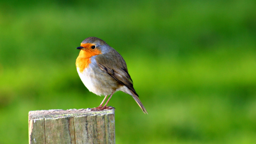

In [5]:
urls = search_images('a bird in forest photo', max_images=3)
dest = 'a bird in forest.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(256,256)

# Build image dataset
Download two types of photos (bird, not bird) and mkdir folders

In [6]:
keywords = 'bird','forest'
path = Path('bird or not')

for o in keywords:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    sleep(10)
    download_images(dest, urls=search_images(f'{o} sun photo'))
    sleep(10)
    download_images(dest, urls=search_images(f'{o} shade photo'))
    sleep(10)

verify all downloaded images (if not success, delete it)

In [7]:
for o in keywords:
    dest = path/o
    failed = verify_images(get_image_files(dest))
    failed.map(Path.unlink)
    print(len(failed))

30
32


## Dataset Loading with Fastai DataBlock

We use `DataBlock` to define the data pipeline, including:

- `ImageBlock`, `CategoryBlock`: input-output types
- `get_image_files`: locate all images from folder
- `RandomSplitter`: split train/valid sets (with seed for reproducibility)
- `parent_label`: use folder name as class label
- `Resize`: resize all images to 192×192 using 'squish' mode


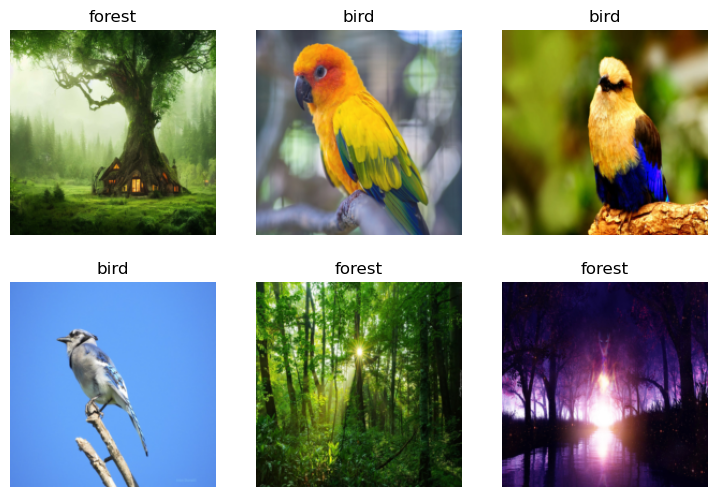

In [8]:
dls = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items= get_image_files,
    splitter= RandomSplitter(valid_pct=0.2, seed=1),
    get_y = parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path)
dls.show_batch(max_n=6)

dataloader is ready, now train it with **vision_learner** + resnet18
# Train a `vision_learner`

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)

**`learn.fine_tune()` in Fastai**

`fine_tune(n_epochs)` is a high-level training utility in Fastai that implements a 2-phase transfer learning strategy:

1.	Phase 1 – Discriminative Pretraining
- The pretrained backbone (base layers) is frozen, and only the final classification head is trained.
- Equivalent to: learn.fit_one_cycle(1) (or custom epochs)

2.	Phase 2 – Full Model Fine-Tuning
- The entire model is unfrozen using learn.unfreeze(), and trained end-to-end with discriminative learning rates.
- Equivalent to: learn.fit_one_cycle(n_epochs) for the full model.

✅ This approach helps retain pretrained knowledge in early layers while adapting deeper layers to the new task, often leading to faster convergence and better generalization.

In [10]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.507483,0.274668,0.068182,00:52


/Users/applewang/miniconda3/envs/fastai/lib/python3.11/site-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,0.175729,0.209600,0.050505,00:52
1,0.123022,0.170639,0.042929,00:50
2,0.071213,0.169943,0.042929,00:50


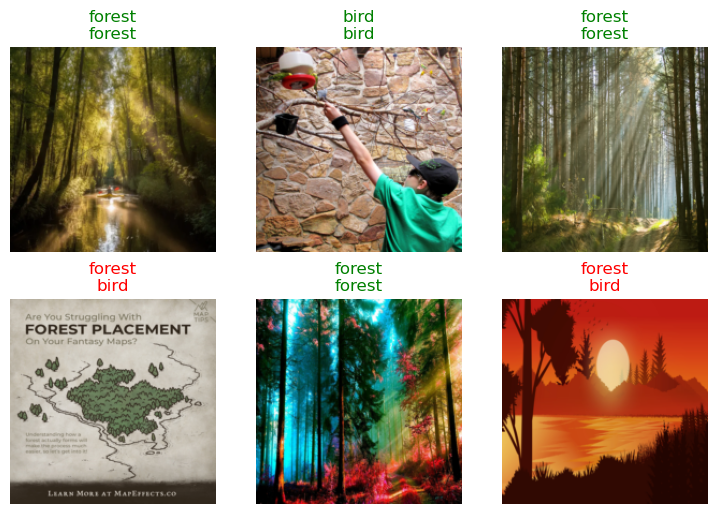

In [11]:
learn.show_results(max_n=6)

# Prediction on a New Image

To perform inference on a new image, we use `learn.predict()` along with Fastai’s `PILImage.create()` utility. 

This wrapper ensures the image is:

- Loaded from disk
- Converted to RGB format (if needed)
- Wrapped into a Fastai-compatible image object


`PILImage.create()` is recommended over `PIL.Image.open()` when using Fastai, as it automatically handles:
- RGB conversion
- Tensor formatting
- Fastai-specific metadata wrapping (e.g., .size, .to_tensor())

In [14]:
from fastai.vision.all import PILImage

# Load and prepare image
img = PILImage.create('a bird in forest.jpg')

# Run prediction
pred_class, pred_idx, probs = learn.predict(img)

# Display results
print(f"Prediction: {pred_class}")
print(f"Confidence: {probs[pred_idx]:.3f}")

Prediction: bird
Confidence: 1.000


<Axes: title={'center': 'Prediction: bird (1.00)'}>

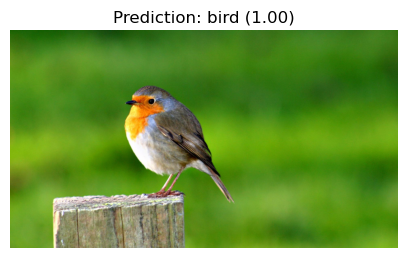

In [15]:
img.show(title=f"Prediction: {pred_class} ({probs[pred_idx]:.2f})")

# Conclusion

In this notebook, we built a lightweight end-to-end image classification pipeline using Fastai to distinguish between **bird** and **non-bird** images.

Key accomplishments:

- 🖼 Automated image collection via DuckDuckGo search
- 🧱 Created a custom dataset folder structure and loaded it using `DataBlock`
- 🧠 Fine-tuned a pre-trained ResNet model using Fastai’s `vision_learner`
- 🔍 Performed inference on unseen images with high confidence
- 💡 Demonstrated a reusable pipeline suitable for binary classification tasks

This mini-project serves as a practical template for:
- Domain-specific classifier bootstrapping (e.g., wildlife, medical, industrial)
- Rapid prototyping with minimal labeled data
- Educational demos or lightweight model deployments
